### Predicting Gym Membership Churn Using XGBoost

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold
import numpy as np
import joblib
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv("gym_churn_synthetic.csv")

In [6]:
df

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,GYM100000,Allison Hill,23.0,Female,"42769 Stone Light Apt. 959, New Jacquelinebury...",323.697.0770x540,Monthly,2024-01-21,2026-05-28,Swimming,64.0,469.0,9367,10.3,No
1,GYM100001,Noah Rhodes,39.0,Male,"911 Courtney Streets Suite 975, North Nancy, I...",+1-945-673-5640x8746,Monthly,2025-07-30,2026-03-17,Yoga,72.0,651.0,7137,13.0,Yes
2,GYM100002,Angie Henderson,35.0,Male,"572 Lawrence Mill, Pattonshire, IN 86699",001-976-322-7203x3428,Monthly,2023-08-26,2026-01-17,Swimming,91.0,644.0,4357,8.8,Yes
3,GYM100003,Daniel Wagner,37.0,Female,"312 Thomas Flat Suite 578, North Christopher, ...",001-527-908-2456x3534,Monthly,2025-02-21,2026-06-07,Cardio,66.0,232.0,6224,13.2,No
4,GYM100004,Cristian Santos,32.0,Female,"594 Alex Mall Suite 495, Albertshire, MH 90338",(585)274-8791x81476,Monthly,2025-10-05,2026-04-21,CrossFit,86.0,650.0,21327,17.7,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,GYM149995,Kenneth Cantu,41.0,Female,"7682 Jessica Drive, Hillberg, NE 54561",307.589.7733,Monthly,2024-01-03,2026-05-31,Yoga,92.0,667.0,14073,12.8,No
49996,GYM149996,Carmen Wilson,46.0,Female,"743 Ernest Shoal, South Markview, GU 51561",244.605.5399x073,Monthly,2024-08-11,2026-04-14,Swimming,68.0,421.0,2438,7.9,Yes
49997,GYM149997,Rachel Reed,39.0,Male,"48826 Booth Plains Apt. 198, Port Nicole, AL 7...",2792306951,Yearly,2025-04-26,2026-05-07,Cycling,76.0,511.0,4628,12.9,No
49998,GYM149998,April Edwards,80.0,Female,"6437 John Oval Apt. 510, Josephport, AR 81518",640.412.3941x26860,Monthly,2025-04-05,2026-05-14,Cardio,74.0,615.0,6783,17.8,No


In [7]:
# Engineer New Features for Predicting Churn

from sklearn.preprocessing import LabelEncoder

cat_cols = ['Gender', 'Membership_Type', 'Favorite_Exercise'] # Gender          is   Female=0, Male=1, Other=2
                                                              # Membership_Type is   Monthly=0, Quarterly=1, Yearly=2
                                                              # Favorite_Exercise is Cardio=0, CrossFit=1, Cycling=2 ...
                                                              

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

#Churn Conversion
df['Churn'] = (df['Churn'] == 'Yes').astype(int)


today = pd.Timestamp('2026-06-10')

# Parse raw date strings to datetime 
df['Join_Date']       = pd.to_datetime(df['Join_Date'])
df['Last_Visit_Date'] = pd.to_datetime(df['Last_Visit_Date'])

# Engineer date features 
df['tenure_months']        = (today - df['Join_Date']).dt.days / 30
df['days_since_visit']     = (today - df['Last_Visit_Date']).dt.days

df['is_new_member']        = (df['tenure_months'] < 3).astype(int)
df['is_gym_veteran']           = (df['tenure_months'] > 24).astype(int)
df['visited_this_week']    = (df['days_since_visit'] <= 7).astype(int)

df['visit_rate_vs_tenure'] = df['Visits_Per_Month'] / (df['tenure_months'] + 1)

# Drop the raw date columns 
df = df.drop(columns=['Join_Date', 'Last_Visit_Date'])

In [8]:
df

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,tenure_months,days_since_visit,is_new_member,is_gym_veteran,visited_this_week,visit_rate_vs_tenure
0,GYM100000,Allison Hill,23.0,0,"42769 Stone Light Apt. 959, New Jacquelinebury...",323.697.0770x540,0,5,64.0,469.0,9367,10.3,0,29.033333,13,0,1,0,0.342952
1,GYM100001,Noah Rhodes,39.0,1,"911 Courtney Streets Suite 975, North Nancy, I...",+1-945-673-5640x8746,0,7,72.0,651.0,7137,13.0,1,10.500000,85,0,0,0,1.130435
2,GYM100002,Angie Henderson,35.0,1,"572 Lawrence Mill, Pattonshire, IN 86699",001-976-322-7203x3428,0,5,91.0,644.0,4357,8.8,1,33.966667,144,0,1,0,0.251668
3,GYM100003,Daniel Wagner,37.0,0,"312 Thomas Flat Suite 578, North Christopher, ...",001-527-908-2456x3534,0,0,66.0,232.0,6224,13.2,0,15.800000,3,0,0,1,0.785714
4,GYM100004,Cristian Santos,32.0,0,"594 Alex Mall Suite 495, Albertshire, MH 90338",(585)274-8791x81476,0,1,86.0,650.0,21327,17.7,0,8.266667,50,0,0,0,1.910072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,GYM149995,Kenneth Cantu,41.0,0,"7682 Jessica Drive, Hillberg, NE 54561",307.589.7733,0,7,92.0,667.0,14073,12.8,0,29.633333,10,0,1,0,0.417845
49996,GYM149996,Carmen Wilson,46.0,0,"743 Ernest Shoal, South Markview, GU 51561",244.605.5399x073,0,5,68.0,421.0,2438,7.9,1,22.266667,57,0,0,0,0.339542
49997,GYM149997,Rachel Reed,39.0,1,"48826 Booth Plains Apt. 198, Port Nicole, AL 7...",2792306951,2,2,76.0,511.0,4628,12.9,0,13.666667,34,0,0,0,0.879545
49998,GYM149998,April Edwards,80.0,0,"6437 John Oval Apt. 510, Josephport, AR 81518",640.412.3941x26860,0,0,74.0,615.0,6783,17.8,0,14.366667,27,0,0,0,1.158351


In [9]:
#See missing Data
df.isna().sum()


Member_ID                     0
Name                          0
Age                         779
Gender                        0
Address                       0
Phone_Number                  0
Membership_Type               0
Favorite_Exercise             0
Avg_Workout_Duration_Min    806
Avg_Calories_Burned         702
Total_Weight_Lifted_kg        0
Visits_Per_Month              0
Churn                         0
tenure_months                 0
days_since_visit              0
is_new_member                 0
is_gym_veteran                0
visited_this_week             0
visit_rate_vs_tenure          0
dtype: int64

As you can see, three of the features in the dataset, Age, Avg_Workout_Duration_Min, and Avg_Calories_Burned all have missing data. In order to aid this I am going to fill in that missing data with the median values and then add another feature that indicates that the feature was filled in. This will allow the neural network to receive all of the available data and learn the data that was filled in so it knows when coming up with predictions


In [10]:
# Age, add missingness flag + median fill
df['age_missing'] = df['Age'].isna().astype(int)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Avg_Workout_Duration_Min, add missingness flag + median fill
df['duration_missing'] = df['Avg_Workout_Duration_Min'].isna().astype(int)
df['Avg_Workout_Duration_Min'] = df['Avg_Workout_Duration_Min'].fillna(df['Avg_Workout_Duration_Min'].median())

# Avg_Calories_Burned - missingness flag + median fill (kept for optional use)
df['calories_missing'] = df['Avg_Calories_Burned'].isna().astype(int)
df['Avg_Calories_Burned'] = df['Avg_Calories_Burned'].fillna(df['Avg_Calories_Burned'].median())

# Verify all NaNs are gone
print(df.isna().sum())

# Sanity check flags
print(f"\nRows flagged as age missing: {df['age_missing'].sum()}")
print(f"Rows flagged as duration missing: {df['duration_missing'].sum()}")
print(f"Rows flagged as calories missing: {df['calories_missing'].sum()}")

Member_ID                   0
Name                        0
Age                         0
Gender                      0
Address                     0
Phone_Number                0
Membership_Type             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
tenure_months               0
days_since_visit            0
is_new_member               0
is_gym_veteran              0
visited_this_week           0
visit_rate_vs_tenure        0
age_missing                 0
duration_missing            0
calories_missing            0
dtype: int64

Rows flagged as age missing: 779
Rows flagged as duration missing: 806
Rows flagged as calories missing: 702


In [11]:
# Print the columns of data
df.columns

Index(['Member_ID', 'Name', 'Age', 'Gender', 'Address', 'Phone_Number',
       'Membership_Type', 'Favorite_Exercise', 'Avg_Workout_Duration_Min',
       'Avg_Calories_Burned', 'Total_Weight_Lifted_kg', 'Visits_Per_Month',
       'Churn', 'tenure_months', 'days_since_visit', 'is_new_member',
       'is_gym_veteran', 'visited_this_week', 'visit_rate_vs_tenure',
       'age_missing', 'duration_missing', 'calories_missing'],
      dtype='str')

In [12]:
# Train test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [13]:
# Scale the continuous columns in the dataset

continuous_cols = [                 # Scale the continuous columns
    'Age',
    'Avg_Workout_Duration_Min',
    'Visits_Per_Month',
    'tenure_months',
    'days_since_visit',
    'visit_rate_vs_tenure'
]

# Scale on the DataFrame BEFORE splitting
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

In [14]:
# Split the Data into feature and target variables
X = df[['Age', 'age_missing', 'Gender', 'Membership_Type', 'Favorite_Exercise', 'Avg_Workout_Duration_Min', 'duration_missing',
        
        # Time and date features
        'Visits_Per_Month', 'tenure_months', 'days_since_visit', 'is_new_member', 'is_gym_veteran', 'visit_rate_vs_tenure']]

y = df['Churn']


In [15]:
# Make train test split
X_train, X_test, y_train, y_test = train_test_split(X,  y,  test_size=0.2, stratify=y, random_state=42)

In [16]:
# Check which columns have NaNs in to ensure nothing is missing
nan_cols = np.isnan(X_train).any(axis=0)
print("Columns with NaN:", np.where(nan_cols)[0])
print("Total NaN values:", np.isnan(X_train).sum())

Columns with NaN: []
Total NaN values: Age                         0
age_missing                 0
Gender                      0
Membership_Type             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
duration_missing            0
Visits_Per_Month            0
tenure_months               0
days_since_visit            0
is_new_member               0
is_gym_veteran              0
visit_rate_vs_tenure        0
dtype: int64


----------

### Begin Creating XGBoost Model

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve)
from sklearn.model_selection import StratifiedKFold
import numpy as np
import joblib

In [18]:
# Calculate pos_weight for class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 2.17


In [19]:
# Define XGBoost model

xgb_model = XGBClassifier(
    n_estimators = 300,             # Number of Trees
    max_depth = 6,                  # depth of each tree
    learning_rate = 0.05,           # the loss shrinkage
    subsample = 0.8,                # % of rows samples per tree
    colsample_bytree = 0.8,          # % of features sampled per tree
    scale_pos_weight = scale_pos_weight,                # handles the class imbalance
    eval_metric = 'auc',
    random_state = 42, 
    n_jobs = -1                     # Use all CPU Cores
)

In [20]:
# Train the model with early stopping


xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_train, y_train), (X_test, y_test)],
    verbose = 50,                    # Print every 50 trees
)

# Retrieve results after fitting
evals_result = xgb_model.evals_result()
print("Training complete.")

[0]	validation_0-auc:0.93945	validation_1-auc:0.93845
[50]	validation_0-auc:0.95028	validation_1-auc:0.94851
[100]	validation_0-auc:0.95288	validation_1-auc:0.94932
[150]	validation_0-auc:0.95538	validation_1-auc:0.94925
[200]	validation_0-auc:0.95896	validation_1-auc:0.94874
[250]	validation_0-auc:0.96338	validation_1-auc:0.94823
[299]	validation_0-auc:0.96702	validation_1-auc:0.94780
Training complete.


In [21]:
# Evaluate model
probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_xgb)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

preds_default = (probs_xgb >= 0.5).astype(int)
preds_optimal = (probs_xgb >= best_threshold).astype(int)

print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs_xgb):.4f}")

print(f"\n------ Default threshold (0.5) ------")
print(confusion_matrix(y_test, preds_default))
print(classification_report(y_test, preds_default,
                             target_names=['Active', 'Churned']))

print(f"\n------ Optimal threshold ({best_threshold:.3f}) ------")
print(confusion_matrix(y_test, preds_optimal))
print(classification_report(y_test, preds_optimal,
                             target_names=['Active', 'Churned']))


Optimal threshold: 0.551
ROC AUC: 0.9478

------ Default threshold (0.5) ------
[[6485  362]
 [ 602 2551]]
              precision    recall  f1-score   support

      Active       0.92      0.95      0.93      6847
     Churned       0.88      0.81      0.84      3153

    accuracy                           0.90     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.90      0.90      0.90     10000


------ Optimal threshold (0.551) ------
[[6584  263]
 [ 660 2493]]
              precision    recall  f1-score   support

      Active       0.91      0.96      0.93      6847
     Churned       0.90      0.79      0.84      3153

    accuracy                           0.91     10000
   macro avg       0.91      0.88      0.89     10000
weighted avg       0.91      0.91      0.91     10000



The model performed very well. Now it is time to plot the AUC for the training vs validation dataset to see if the data was overfitted.

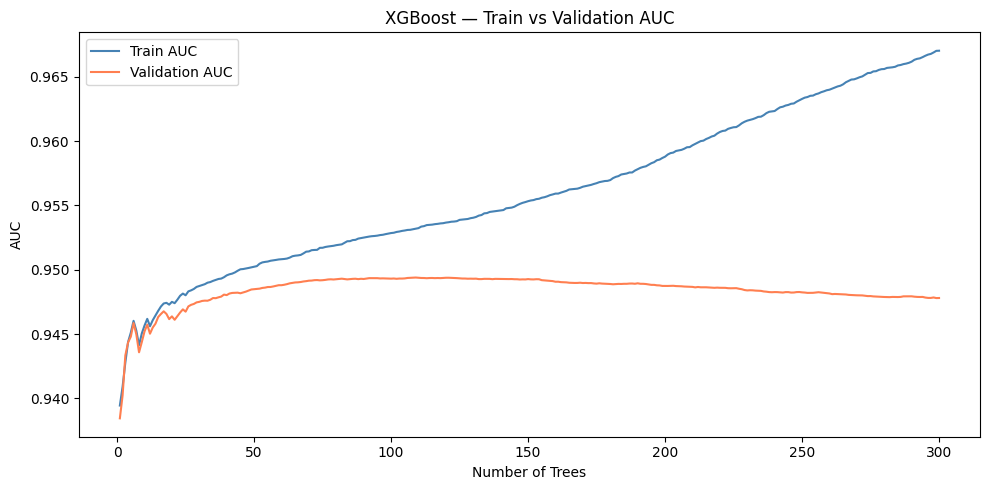

Final Train AUC: 0.9670
Final Val AUC:   0.9478
Gap:             0.0192
No overfitting detected


In [22]:
import matplotlib.pyplot as plt

train_auc = evals_result['validation_0']['auc']
val_auc   = evals_result['validation_1']['auc']
epochs    = range(1, len(train_auc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_auc, label='Train AUC',      color='steelblue')
plt.plot(epochs, val_auc,   label='Validation AUC', color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('AUC')
plt.title('XGBoost — Train vs Validation AUC')
plt.legend()
plt.tight_layout()
plt.show()

final_train_auc = train_auc[-1]
final_val_auc   = val_auc[-1]
gap             = final_train_auc - final_val_auc

print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Val AUC:   {final_val_auc:.4f}")
print(f"Gap:             {gap:.4f}")

if gap < 0.02:
    print("No overfitting detected")
elif gap < 0.05:
    print("Mild overfitting")
else:
    print("Overfitting")

As we can see from the plot, at around 50-75 trees is where the AUC for the number of trees on the validation dataset starts to flatten when the AUC of the training data still rises.

As a result I will further fine tune the model by using Optuna to find the best parameters.

Optuna is a python library which uses Bayesian optimization to tune the best parameters for the model

In [23]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':    300,
        'max_depth':       trial.suggest_int('max_depth', 3, 8),
        'learning_rate':   trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':       trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': scale_pos_weight,
        'eval_metric':     'auc',
        'early_stopping_rounds': 20,
        'random_state':    42,
        'n_jobs':          -1
    }

    model = XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )

    return roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest Val AUC:  {study.best_value:.4f}")
print(f"Best params:   {study.best_params}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Best trial: 16. Best value: 0.949443: 100%|██████████| 30/30 [00:16<00:00,  1.83it/s]


Best Val AUC:  0.9494
Best params:   {'max_depth': 5, 'learning_rate': 0.058939900384983965, 'subsample': 0.7771947292561029, 'colsample_bytree': 0.842233477415514}


In [24]:
# Now I am going to retrain the model to use the best parameters

best = study.best_params

xgb_final = XGBClassifier(
    n_estimators=300,
    max_depth=best['max_depth'],
    learning_rate=best['learning_rate'],
    subsample=best['subsample'],
    colsample_bytree=best['colsample_bytree'],
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    early_stopping_rounds=20,
    random_state=42,
    n_jobs=-1
)

xgb_final.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=50
)

evals_result = xgb_final.evals_result()
print("Training complete.")

[0]	validation_0-auc:0.93208	validation_1-auc:0.93056
[50]	validation_0-auc:0.94916	validation_1-auc:0.94845
[100]	validation_0-auc:0.95108	validation_1-auc:0.94939
[132]	validation_0-auc:0.95217	validation_1-auc:0.94926
Training complete.


In [25]:
# Evaluate model
probs_xgb = xgb_final.predict_proba(X_test)[:, 1]

# Find optimal threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, probs_xgb)
f1_scores      = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

preds_default = (probs_xgb >= 0.5).astype(int)
preds_optimal = (probs_xgb >= best_threshold).astype(int)

print("OPTIMIZED PARAMETERS")
print(f"\nOptimal threshold: {best_threshold:.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, probs_xgb):.4f}")

print(f"\n------ Default threshold (0.5) ------")
print(confusion_matrix(y_test, preds_default))
print(classification_report(y_test, preds_default,
                             target_names=['Active', 'Churned']))

print(f"\n------ Optimal threshold ({best_threshold:.3f}) ------")
print(confusion_matrix(y_test, preds_optimal))
print(classification_report(y_test, preds_optimal,
                             target_names=['Active', 'Churned']))

OPTIMIZED PARAMETERS

Optimal threshold: 0.531
ROC AUC: 0.9494

------ Default threshold (0.5) ------
[[6462  385]
 [ 584 2569]]
              precision    recall  f1-score   support

      Active       0.92      0.94      0.93      6847
     Churned       0.87      0.81      0.84      3153

    accuracy                           0.90     10000
   macro avg       0.89      0.88      0.89     10000
weighted avg       0.90      0.90      0.90     10000


------ Optimal threshold (0.531) ------
[[6536  311]
 [ 611 2542]]
              precision    recall  f1-score   support

      Active       0.91      0.95      0.93      6847
     Churned       0.89      0.81      0.85      3153

    accuracy                           0.91     10000
   macro avg       0.90      0.88      0.89     10000
weighted avg       0.91      0.91      0.91     10000



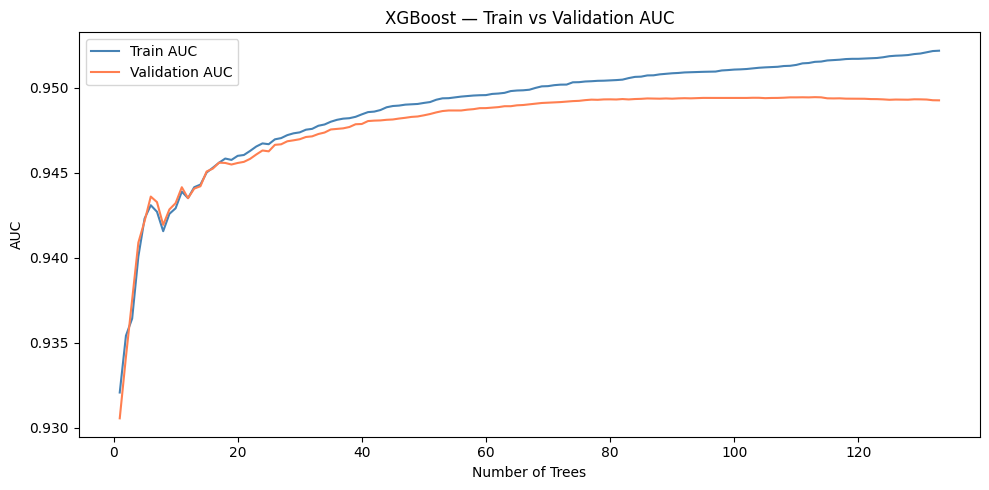

Final Train AUC: 0.9522
Final Val AUC:   0.9493
Gap:             0.0029
No overfitting detected


In [26]:
train_auc = evals_result['validation_0']['auc']
val_auc   = evals_result['validation_1']['auc']
epochs    = range(1, len(train_auc) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_auc, label='Train AUC',      color='steelblue')
plt.plot(epochs, val_auc,   label='Validation AUC', color='coral')
plt.xlabel('Number of Trees')
plt.ylabel('AUC')
plt.title('XGBoost — Train vs Validation AUC')
plt.legend()
plt.tight_layout()
plt.show()

final_train_auc = train_auc[-1]
final_val_auc   = val_auc[-1]
gap             = final_train_auc - final_val_auc

print(f"Final Train AUC: {final_train_auc:.4f}")
print(f"Final Val AUC:   {final_val_auc:.4f}")
print(f"Gap:             {gap:.4f}")

if gap < 0.02:
    print("No overfitting detected")
elif gap < 0.05:
    print("Mild overfitting")
else:
    print("Overfitting")

In [28]:
print(f"Best number of n_estimators: {xgb_final.best_iteration}")
print(f"Best parameters used: {study.best_params}")

Best number of n_estimators: 112
Best parameters used: {'max_depth': 5, 'learning_rate': 0.058939900384983965, 'subsample': 0.7771947292561029, 'colsample_bytree': 0.842233477415514}


For this model Optuna found that the best number of n_estimators to use was exactly 112, and the other best parameters used were a max depth of 5, a learning rate of 0.058939900384983965, a subsample ratio of 0.7771947292561029, and a colsample_bytree ratio of 0.842233477415514.